### <font color = "orange"> Q1. Load the texture dataset from OpenML: https://www.openml.org/search?type=data&sort=version&status=any&order=asc&exact_name=texture&id=40499 (1 Mark)

In [ ]:
from sklearn.datasets import fetch_openml

# Load the texture dataset from OpenML
texture = fetch_openml(data_id=40499, as_frame=True)


# Display basic information
print("Features shape:", texture.data.shape)
print("Target shape:", texture.target.shape)
print("Feature names:", texture.feature_names)
print("Target classes:", texture.target.unique())

Features shape: (5500, 40)
Target shape: (5500,)
Feature names: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40']
Target classes: ['5', '6', '7', '11', '1', ..., '8', '10', '2', '3', '4']
Length: 11
Categories (11, object): ['1', '10', '11', '2', ..., '6', '7', '8', '9']


In [ ]:
!pip install openml

### <font color = "orange"> Q2. Show the class distribution of the dataset and state whether the dataset is well balanced or not. (2 Marks)


Class Distribution: Class
5     500
6     500
7     500
11    500
1     500
9     500
8     500
10    500
2     500
3     500
4     500
Name: count, dtype: int64

Class Distribution:  Class
5     9.090909
6     9.090909
7     9.090909
11    9.090909
1     9.090909
9     9.090909
8     9.090909
10    9.090909
2     9.090909
3     9.090909
4     9.090909
Name: count, dtype: float64


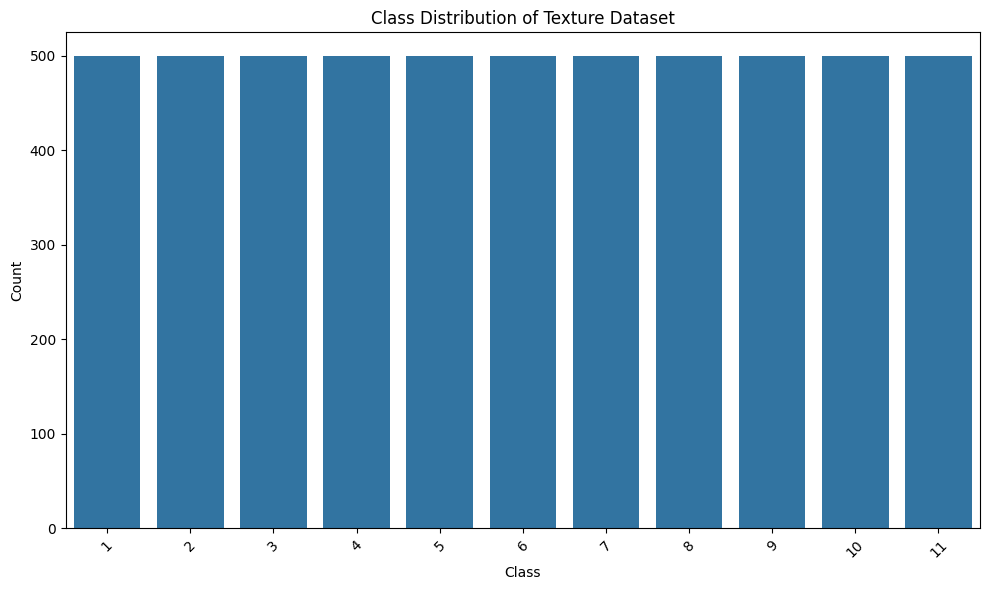

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

y = texture.target
y = y.astype(int)
class_counts = y.value_counts()
print("Class Distribution:", class_counts)

class_percentage = (class_counts / len(y))*100
print("\nClass Distribution: ", class_percentage)

plt.figure(figsize=(10, 6))
sns.countplot(data=pd.DataFrame({'class': y}), x='class')
plt.title('Class Distribution of Texture Dataset')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### <font color = "orange"> Q3. Split the dataset into training and test sets (80%-20%) (1 Marks)

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(texture.data, y, test_size=0.2, random_state=42, stratify=texture.target)


# Display the shapes of the resulting sets
print("Training set shapes:")
print(f"X_train: {x_train.shape}")
print(f"y_train: {y_train.shape}")

print("\nTest set shapes:")
print(f"X_test: {x_test.shape}")
print(f"y_test: {y_test.shape}")

# Verify that the split maintains class balance
print("\nClass distribution in training set:")
print(y_train.value_counts().sort_index())

print("\nClass distribution in test set:")
print(y_test.value_counts().sort_index())

# Calculate the split percentages
total_samples = len(texture.target)
train_samples = len(y_train)
test_samples = len(y_test)

print(f"\nSplit Summary:")
print(f"Total samples: {total_samples}")
print(f"Training samples: {train_samples} ({train_samples/total_samples*100:.1f}%)")
print(f"Test samples: {test_samples} ({test_samples/total_samples*100:.1f}%)")

Training set shapes:
X_train: (4400, 40)
y_train: (4400,)

Test set shapes:
X_test: (1100, 40)
y_test: (1100,)

Class distribution in training set:
Class
1     400
2     400
3     400
4     400
5     400
6     400
7     400
8     400
9     400
10    400
11    400
Name: count, dtype: int64

Class distribution in test set:
Class
1     100
2     100
3     100
4     100
5     100
6     100
7     100
8     100
9     100
10    100
11    100
Name: count, dtype: int64

Split Summary:
Total samples: 5500
Training samples: 4400 (80.0%)
Test samples: 1100 (20.0%)


### <font color = "orange">Q4. Scale the features of the dataset appropriately such that all the features take values in the same range. (3 Marks)

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

### <font color = "orange">Q5. Design a Gaussian Naive Bayes’ (NB) classifier and fit it on the training set (6 Marks)

In [ ]:
from scipy.stats import norm
class GaussianNaiveBayes:
    def __init__(self):
        self.classes = None
        self.class_priors = None
        self.means = None
        self.variances = None

    def fit(self, x, y):

        self.classes = np.unique(y)
        n_classes = len(self.classes)
        n_features = x.shape[1]

        self.class_priors = np.zeros(n_classes)
        self.means = np.zeros((n_classes, n_features))
        self.variances = np.zeros((n_classes, n_features))

        for i, c in enumerate(self.classes):
            x_c = x[y == c]
            self.class_priors[i] = len(x_c) / len(x)
            self.means[i, :] = np.mean(x_c, axis=0)
            self.variances[i,:] = np.var(x_c, axis=0, ddof=1) # delta degrees of freedom (n-1)

            # add small epsilon to avoid division by zero
            self.variances[i,:] = np.maximum(self.variances[i,:], 1e-9)

    def calculate_likelihood(self, x):
        n_samples = x.shape[0]
        n_classes = len(self.classes)
        likelihoods = np.zeros((n_samples, n_classes))

        for i in range(n_classes):
            for j in range(n_samples):

                feature_likelihoods = norm.pdf(x[j, :], self.means[i, :], np.sqrt(self.variances[i,:]))
                likelihoods[j, i] = np.prod(feature_likelihoods)

        return likelihoods

    def predict(self, x):
        likelihoods = self.calculate_likelihood(x)
        posteriors = likelihoods*self.class_priors
        predictions = self.classes[np.argmax(posteriors, axis=1)]
        return predictions

    def predict_prob(self, x):
        likelihoods = self.calculate_likelihood(x)
        posteriors = likelihoods*self.class_priors

        posteriors_sum = np.sum(posteriors, axis=1, keepdims=True)
        probabilities = posteriors / posteriors_sum
        return probabilities



In [ ]:
# create and fit the Gaussian Naive Bayes classifier
gnb_scratch = GaussianNaiveBayes()
gnb_scratch.fit(x_train_scaled, y_train)


### <font color = "orange">Q6. Evaluate the test set using the Gaussian NB classifier you learned from the training data and report the performance in terms of accuracy, precision, recall and confusion matrix. (4 Marks)

Training Accuracy: 0.7736 (77.36%)
Test Accuracy: 0.7618 (76.18%)
Training Set:
  Accuracy:  0.7736 (77.36%)
  Precision: 0.7778 (77.78%)
  Recall:    0.7736 (77.36%)

Test Set:
  Accuracy:  0.7618 (76.18%)
  Precision: 0.7618 (76.18%)
  Recall:    0.7618 (76.18%)


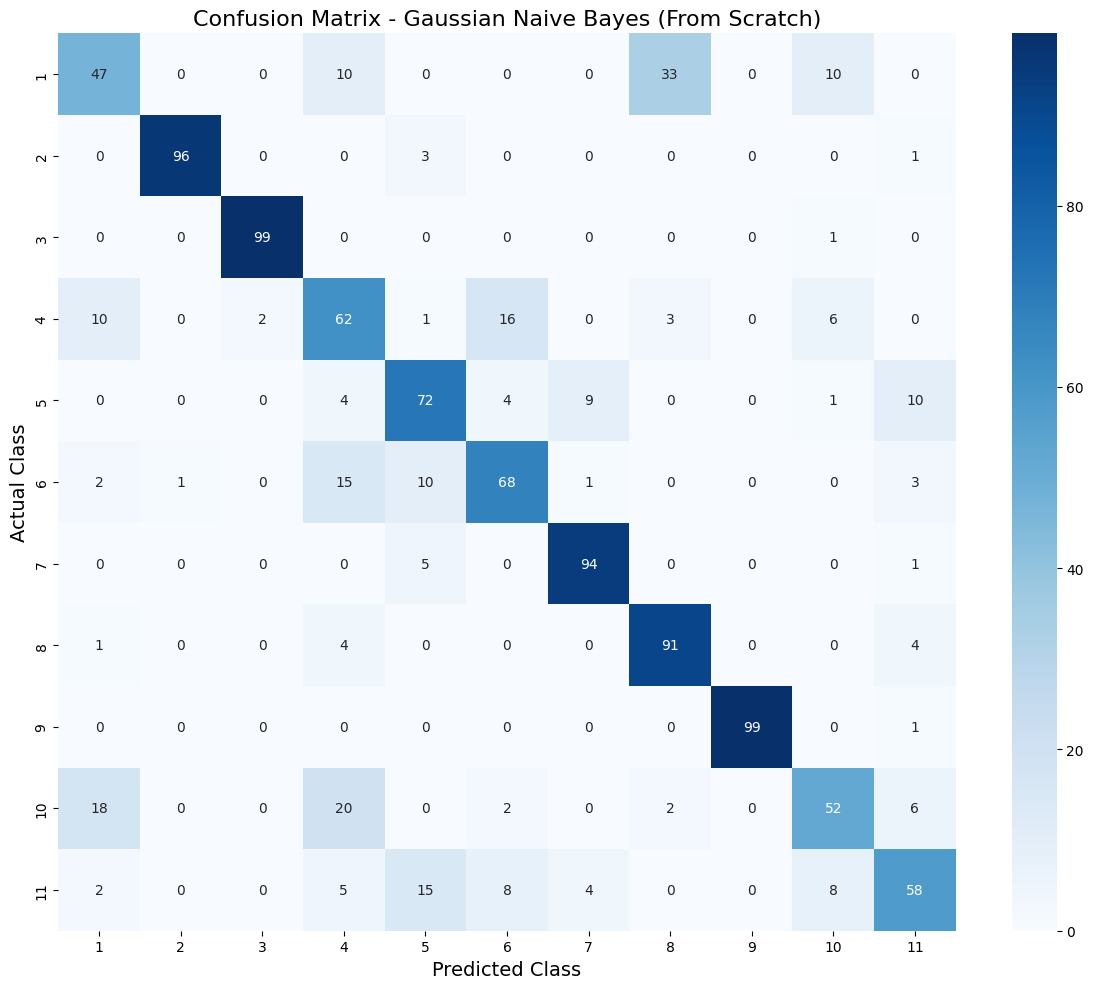

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix


# make predictions
y_train_pred = gnb_scratch.predict(x_train_scaled)
y_test_pred = gnb_scratch.predict(x_test_scaled)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_precision = precision_score(y_train, y_train_pred, average='macro', zero_division=0)
test_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)

train_recall = recall_score(y_train, y_train_pred, average='macro', zero_division=0)
test_recall = recall_score(y_test, y_test_pred, average='macro', zero_division=0)


print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print(f"Training Set:")
print(f"  Accuracy:  {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  Precision: {train_precision:.4f} ({train_precision*100:.2f}%)")
print(f"  Recall:    {train_recall:.4f} ({train_recall*100:.2f}%)")

print(f"\nTest Set:")
print(f"  Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  Precision: {test_precision:.4f} ({test_precision*100:.2f}%)")
print(f"  Recall:    {test_recall:.4f} ({test_recall*100:.2f}%)")

cm = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, 12), yticklabels=range(1, 12))
plt.title('Confusion Matrix - Gaussian Naive Bayes (From Scratch)', fontsize=16)
plt.xlabel('Predicted Class', fontsize=14)
plt.ylabel('Actual Class', fontsize=14)
plt.tight_layout()
plt.show()



### <font color = "orange">Q7. Using scikit-learn's implementation of Gaussian NB classifier, fit the training data. (1 Mark)

In [ ]:
from sklearn.naive_bayes import GaussianNB
sklearn_gnb = GaussianNB()
sklearn_gnb.fit(x_train_scaled, y_train)
y_train_pred_sklearn = sklearn_gnb.predict(x_train_scaled)
y_test_pred_sklearn = sklearn_gnb.predict(x_test_scaled)


### <font color="orange">Q8. Evaluate the scikit-learn's Gaussian NB model on the test set. How does the performance of this model compare with your custom implementation? (2 Marks)

Scikit-learn Gaussian Naive Bayes Performance Metrics:
Training Set:
  Accuracy:  0.7734 (77.34%)
  Precision: 0.7776 (77.76%)
  Recall:    0.7734 (77.34%)

Test Set:
  Accuracy:  0.7618 (76.18%)
  Precision: 0.7618 (76.18%)
  Recall:    0.7618 (76.18%)


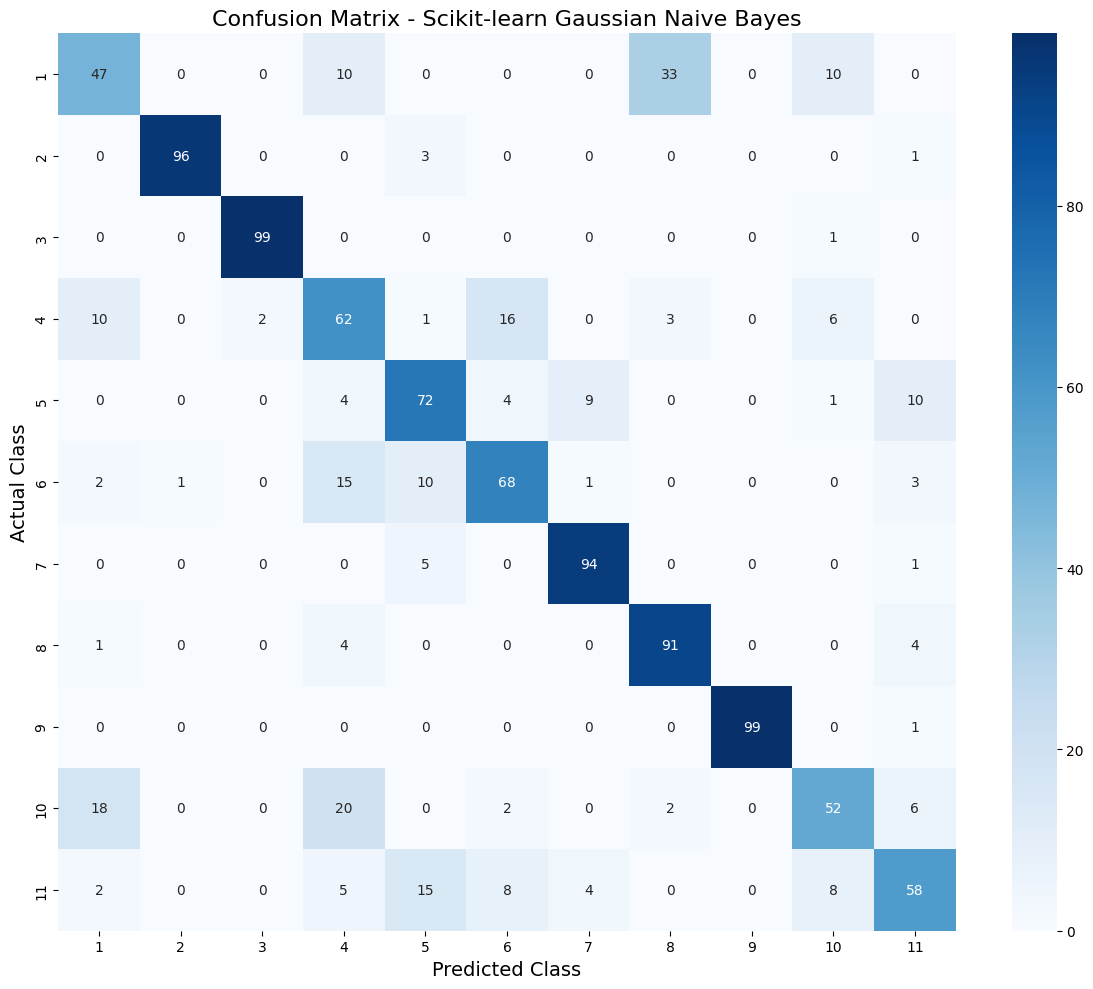

In [ ]:
# Calculate performance metrics
train_accuracy_sklearn = accuracy_score(y_train, y_train_pred_sklearn)
test_accuracy_sklearn = accuracy_score(y_test, y_test_pred_sklearn)

train_precision_sklearn = precision_score(y_train, y_train_pred_sklearn, average='macro', zero_division=0)
test_precision_sklearn = precision_score(y_test, y_test_pred_sklearn, average='macro', zero_division=0)

train_recall_sklearn = recall_score(y_train, y_train_pred_sklearn, average='macro', zero_division=0)
test_recall_sklearn = recall_score(y_test, y_test_pred_sklearn, average='macro', zero_division=0)

print("Scikit-learn Gaussian Naive Bayes Performance Metrics:")
print("=" * 70)
print(f"Training Set:")
print(f"  Accuracy:  {train_accuracy_sklearn:.4f} ({train_accuracy_sklearn*100:.2f}%)")
print(f"  Precision: {train_precision_sklearn:.4f} ({train_precision_sklearn*100:.2f}%)")
print(f"  Recall:    {train_recall_sklearn:.4f} ({train_recall_sklearn*100:.2f}%)")

print(f"\nTest Set:")
print(f"  Accuracy:  {test_accuracy_sklearn:.4f} ({test_accuracy_sklearn*100:.2f}%)")
print(f"  Precision: {test_precision_sklearn:.4f} ({test_precision_sklearn*100:.2f}%)")
print(f"  Recall:    {test_recall_sklearn:.4f} ({test_recall_sklearn*100:.2f}%)")

# Create confusion matrix
cm_sklearn = confusion_matrix(y_test, y_test_pred_sklearn)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, 12), yticklabels=range(1, 12))
plt.title('Confusion Matrix - Scikit-learn Gaussian Naive Bayes', fontsize=16)
plt.xlabel('Predicted Class', fontsize=14)
plt.ylabel('Actual Class', fontsize=14)
plt.tight_layout()
plt.show()